In [1]:
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import xml2epub
import time
import re


In [2]:
# URL da página do capitulo inicial apartir da qual você deseja extrair dados
#url = 'https://www.royalroad.com/fiction/86184/rise-of-the-living-enchantment-litrpg-regression/chapter/1766104/thirty-nine-gangnar'
url = input('Enter chapter URL')

# Faz a requisição HTTP para a página
response = requests.get(url)

# Verifica se a requisição foi bem-sucedida (status code 200)
if response.status_code == 200:
    # Cria o objeto BeautifulSoup para fazer o parsing do HTML
    soup = BeautifulSoup(response.text, 'html.parser')
else:
    print("Falha ao acessar a página:", response.status_code)

In [3]:
ficHeader = soup.find('div', class_='fic-header').a
urlBase = "https://www.royalroad.com"
urlFic = urlBase + ficHeader["href"]
ficTitle = ficHeader.h2.get_text()

# limpa o titulo de caracteres inválidos para nomes de arquivos
ficTitle = re.sub(r'[<>:"/\\|?*]', '-', ficTitle)


In [4]:
#busca a pagina principal da novel para extrair a capa do livro
response = requests.get(urlFic)

if response.status_code == 200:
    fic_soup = BeautifulSoup(response.text, 'html.parser')
else:
    print("Falha ao acessar a página:", response.status_code)

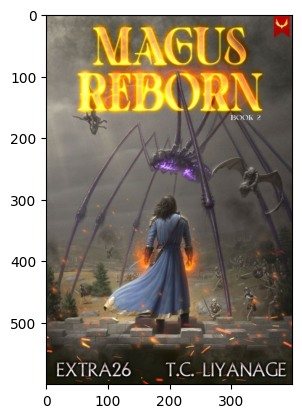

In [5]:
# extrai a url da imagem da capa e salva localmente
img_url = fic_soup.find('img', class_='thumbnail')['src']
img_data = requests.get(img_url).content 
f = open('./covers/cover_img.jpg', 'wb')
f.write(img_data)
f.close()

img = plt.imread('./covers/cover_img.jpg')
plt.imshow(img)

In [6]:
book = xml2epub.Epub(ficTitle, language='en')
## cria a capa do livro a partir da imagem baixada e adiciona ao livro
coverChapter = xml2epub.create_chapter_from_string('./covers/cover_img.jpg', local=True, title='Cover', strict=False)
book.add_chapter(coverChapter)

In [7]:
def getNextChapter(soup) :
    # Encontra o botão "Next Chapter" e extrai a URL do próximo capítulo
    nextBtn = soup.find('div', class_='col-md-offset-4').a
    nextUrl = urlBase + nextBtn["href"]

    # Faz a requisição da página do próximo capítulo
    response = requests.get(nextUrl)

    # Verifica se a requisição foi bem-sucedida (status code 200)
    if response.status_code == 200:
        # Cria o objeto BeautifulSoup para fazer o parsing do HTML do capitulo
        soup = BeautifulSoup(response.text, 'html.parser')
        # print(soup)
    else:
        print("Falha ao acessar a página:", response.status_code)
        
    return soup

In [8]:
try:
    # alguns capítulos têm nomes de classe diferentes para a mensagem de aviso, e alguns usam "span ou divs" para outros elementos
    # então precisamos verificar ambos os casos
    # faça um teste para sua novel para testar se ela tem mensagens de aviso ou se está deletando texto importante
    # warning = soup.find('div', class_='chapter-content').div
    chapterContent = soup.find('div', class_='chapter-content')
    warning = chapterContent.find('span', class_=True)
    # print(print(w.text))
    print(warning)
    # warning.decompose()
except:
    # print("No warning found")
    pass

<span class="cmY5YmVkMWRjNTNkNzQzZTNhNzJhMzQ5M2UzMDYwNjBl"><br/>The tale has been stolen; if detected on Amazon, report the violation.<br/></span>


In [9]:
numChapters = int(input('Number of chapters that you want in this book: '))

In [10]:
for i in range(1, numChapters+1):
    try:
        # some chapters have different class names for the warning message, and some use "span or divs" for other elements
        # so we need to check for both cases
        # make a test for your fiction to see if it has a warning messages or it is deleting important text
        chapterContent = soup.find('div', class_='chapter-content')
        warning = chapterContent.find('span', class_=True) or chapterContent.find('div', class_=True)
        # print("Warning found: ", warning.text)
        warning.decompose()
    except:
        # print("No warning found")
        pass
    
    chapterTitle = str(soup.h1)
    chapterText = str(soup.find('div', class_='chapter-content'))
    chapterText = chapterTitle + chapterText

    print (f"{i} - Found: {soup.h1.text} ----- Adding Chapter...")
    ## create chapter
    chapterTitle = soup.h1.text
    ficChapter = xml2epub.create_chapter_from_string(chapterText, url=url, title=chapterTitle, strict=False)
    book.add_chapter(ficChapter)

    time.sleep(0.6)
    try:
        soup = getNextChapter(soup)
    except:
        print("There is no next chapter")
        break

1 - Found: 279. Merchant in War (Volume 5 starts) ----- Adding Chapter...
2 - Found: 280. Desire of conquest ----- Adding Chapter...
3 - Found: 281. State of the kingdom ----- Adding Chapter...
4 - Found: 282. Against tyranny ----- Adding Chapter...
5 - Found: 283. Coronation ----- Adding Chapter...
6 - Found: 284. Messengers ----- Adding Chapter...
7 - Found: 285. The plan (1) ----- Adding Chapter...
8 - Found: 286. The plan (2) ----- Adding Chapter...
9 - Found: 287. I'm sorry, son ----- Adding Chapter...
10 - Found: 288. Cloudy ----- Adding Chapter...
11 - Found: 289. Helpless ----- Adding Chapter...
12 - Found: 290. Tent tactics ----- Adding Chapter...
13 - Found: 291. Watcher's Worth ----- Adding Chapter...
14 - Found: 292. Siege of Solmere ----- Adding Chapter...
15 - Found: 293. Mage killer ----- Adding Chapter...
16 - Found: 294. No place to run ----- Adding Chapter...
17 - Found: 295. Cousinly tensions ----- Adding Chapter...
18 - Found: 296. Selenia ----- Adding Chapter...
19

In [11]:
book.create_epub('./books/')


'./books/Magus Reborn (Stubbed).epub'